In [1]:
#import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
#load dataset

In [4]:
df = pd.read_csv("customer_behavior.csv")
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [5]:
df.shape

(5000, 7)

In [6]:
df.isnull().sum()

CustomerID           0
Gender              97
Region             175
PurchaseAmount     150
ProductCategory    526
Churn              265
CampaignGroup      185
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [8]:
df.describe()

,CustomerID,PurchaseAmount
count,5000.000000,4850.000000
mean,3500.500000,1003.950670
std,1443.520003,482.113122
min,1001.000000,0.000000
25%,2250.750000,673.642500
50%,3500.500000,998.080000
75%,4750.250000,1327.077500
max,6000.000000,2688.880000


In [9]:
#Clean PurchaseAmount

In [10]:
purchase_data = df.dropna(subset=["PurchaseAmount"])

In [11]:
purchase_data["PurchaseAmount"].isnull().sum()

np.int64(0)

In [12]:
mean =df["PurchaseAmount"].mean()
print('Mean:',mean)

Mean: 1003.9506701030928


In [13]:
median = df["PurchaseAmount"].median()
print('Median:',median)

Median: 998.0799999999999


In [14]:
mode = df["PurchaseAmount"].mode()
print('Mode:',mode)

Mode: 0    0.0
Name: PurchaseAmount, dtype: float64


In [15]:
#Visualize PurchaseAmount

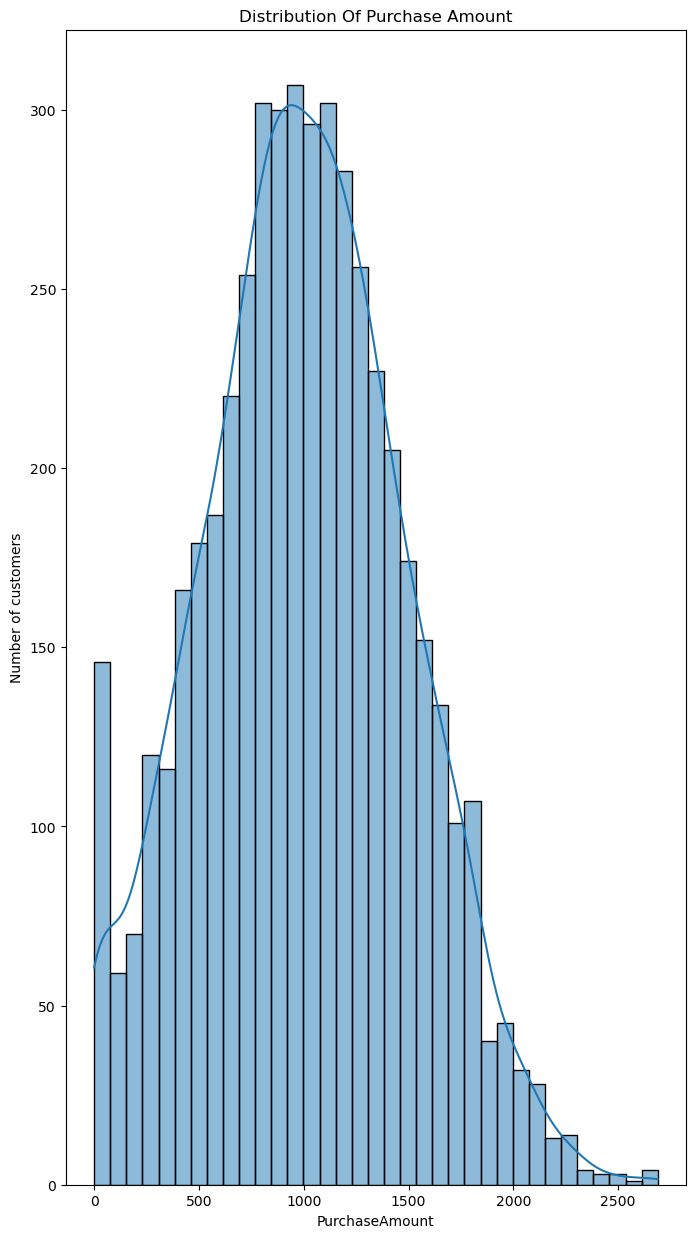

In [16]:
plt.figure(figsize=(8,15))

sns.histplot(
    purchase_data["PurchaseAmount"],
    kde=True
)
plt.title("Distribution Of Purchase Amount")
plt.xlabel("PurchaseAmount")
plt.ylabel("Number of customers")
plt.show()

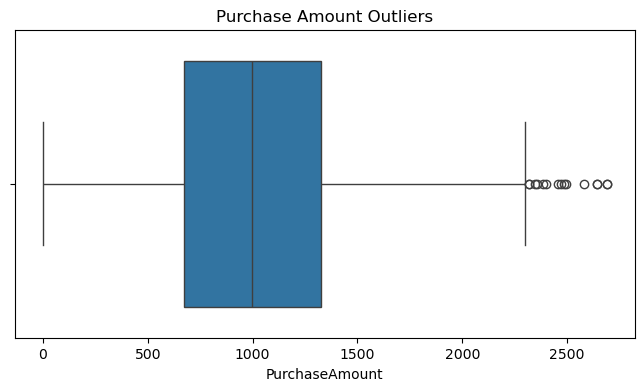

In [17]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=purchase_data["PurchaseAmount"]
)
plt.title("Purchase Amount Outliers")
plt.show()

In [18]:
#calculate IQR

In [19]:
Q1 = purchase_data["PurchaseAmount"].quantile(0.25)
Q3 = purchase_data["PurchaseAmount"].quantile(0.75)

IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 673.6424999999999
Q3: 1327.0775
IQR: 653.4350000000002


In [20]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

Lower: -306.51000000000033
Upper: 2307.2300000000005


In [21]:
#outliers

In [22]:
outliers = purchase_data[
    (purchase_data["PurchaseAmount"] < lower_bound) |
    (purchase_data["PurchaseAmount"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 15


In [23]:
skewness = purchase_data["PurchaseAmount"].skew()

kurtosis = purchase_data["PurchaseAmount"].kurtosis()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 0.10609189374631554
Kurtosis: -0.2615105545319705


In [24]:
df.groupby("Gender")["PurchaseAmount"].mean()

Gender
Female     987.872046
Male      1019.176609
Name: PurchaseAmount, dtype: float64

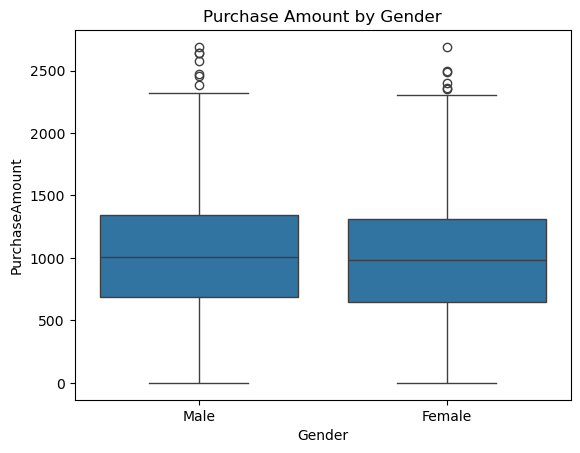

In [25]:
sns.boxplot(
    data=df,
    x="Gender",
    y="PurchaseAmount"
)

plt.title("Purchase Amount by Gender")

plt.show()

In [26]:
#perform t test

In [27]:
male = df[
    df["Gender"] == "Male"
]["PurchaseAmount"].dropna()

female = df[
    df["Gender"] == "Female"
]["PurchaseAmount"].dropna()

In [28]:
t_stat, p_value = stats.ttest_ind(
    male,
    female,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 2.234798912073049
p-value: 0.025476849797238143


In [29]:
#chi square test

In [30]:
table = pd.crosstab(
    df["ProductCategory"],
    df["Churn"]
)

print(table)

Churn             No  Yes
ProductCategory          
Electronics      785  541
Fashion          839  607
Grocery          855  604


In [31]:
chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p_value)

Chi-square: 0.3960436652673918
p-value: 0.8203519424988512


In [32]:
#one way anova

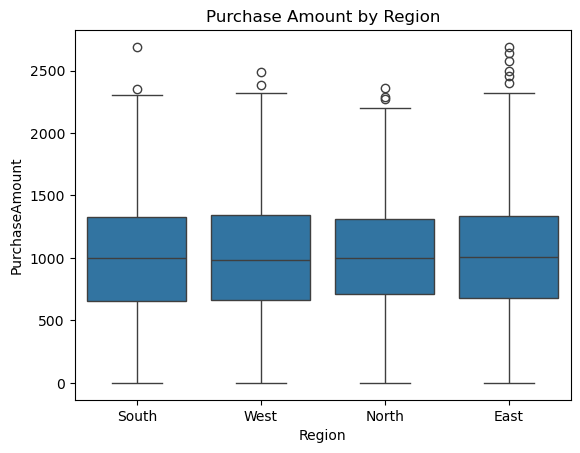

In [33]:
sns.boxplot(
    data=df,
    x="Region",
    y="PurchaseAmount"
)

plt.title("Purchase Amount by Region")

plt.show()

In [34]:
region_data = df.dropna(
    subset=["Region", "PurchaseAmount"]
)

groups = [
    group["PurchaseAmount"].values
    for name, group in region_data.groupby("Region")
]

In [35]:
f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.38966786354806715
p-value: 0.760452802731563


In [36]:
df.groupby("CampaignGroup")["PurchaseAmount"].mean()

CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64

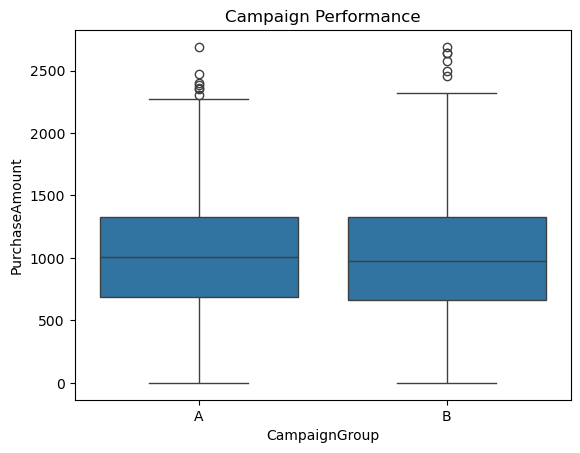

In [37]:
sns.boxplot(
    data=df,
    x="CampaignGroup",
    y="PurchaseAmount"
)

plt.title("Campaign Performance")

plt.show()

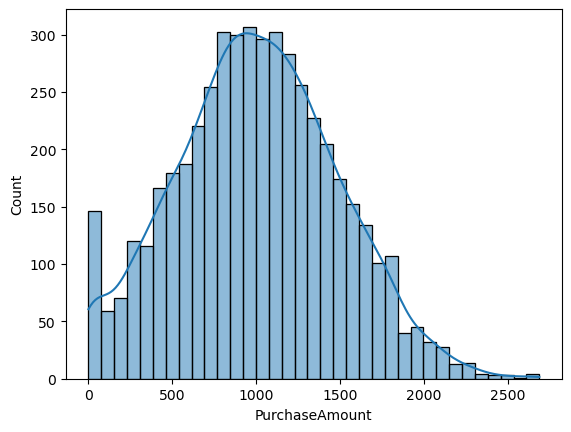

In [38]:
sns.histplot(
    purchase_data["PurchaseAmount"],
    kde=True
)

plt.show()

In [39]:
sample_means = []

for i in range(1000):
    sample = purchase_data["PurchaseAmount"].sample(
        n=30,
        replace=True
    )

    sample_means.append(sample.mean())

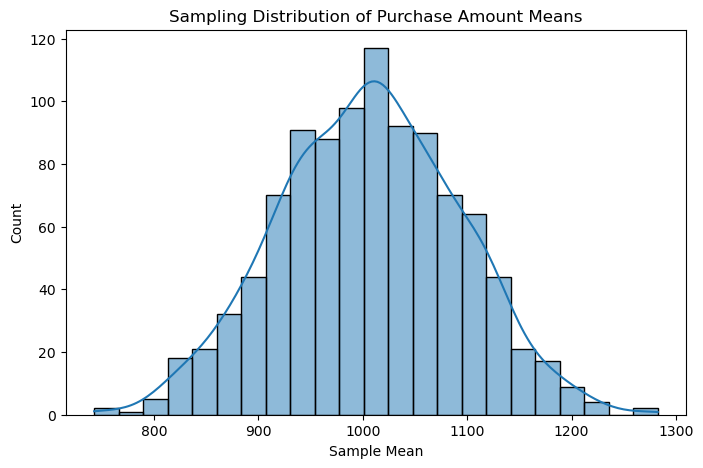

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(sample_means, kde=True)

plt.title("Sampling Distribution of Purchase Amount Means")
plt.xlabel("Sample Mean")

plt.show()

In [42]:
mean = purchase_data["PurchaseAmount"].mean()

std = purchase_data["PurchaseAmount"].std()

n = len(purchase_data)

print("Mean:", mean)
print("Standard deviation:", std)
print("Sample size:", n)

Mean: 1003.9506701030928
Standard deviation: 482.11312193311596
Sample size: 4850


In [43]:
SE = std / np.sqrt(n)

print("Standard Error:", SE)

Standard Error: 6.922740985370979


In [44]:
confidence = 0.95

t_critical = stats.t.ppf(
    (1 + confidence) / 2,
    df=n-1
)

margin_error = t_critical * SE

lower = mean - margin_error
upper = mean + margin_error

print("Lower:", lower)
print("Upper:", upper)

Lower: 990.3789594609216
Upper: 1017.522380745264


95% Confidence Interval:
₹990.58 to ₹1017.32